In [27]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [28]:
import subprocess, sys

packages = [
    "pandas", "numpy", "matplotlib", "seaborn",
    "nltk", "scikit-learn", "vaderSentiment", "gradio"
]
for pkg in packages:
    subprocess.run([sys.executable, "-m", "pip", "install", pkg, "-q"], check=False)

print("All packages installed successfully.")

All packages installed successfully.


In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re, string, warnings
warnings.filterwarnings("ignore")

import nltk
nltk.download("punkt",     quiet=True)
nltk.download("stopwords", quiet=True)
nltk.download("wordnet",   quiet=True)
nltk.download("punkt_tab", quiet=True)

from nltk.corpus   import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem     import WordNetLemmatizer

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.model_selection         import train_test_split
from sklearn.naive_bayes             import MultinomialNB
from sklearn.linear_model            import LogisticRegression
from sklearn.metrics                 import (classification_report,
                                             confusion_matrix,
                                             precision_score, recall_score,
                                             f1_score, accuracy_score)
from sklearn.decomposition           import NMF
from vaderSentiment.vaderSentiment   import SentimentIntensityAnalyzer

print("All imports successful.")

All imports successful.


In [30]:
try:
    df_full = pd.read_csv("Womens Clothing E-Commerce Reviews.csv")
    df_full = df_full[["Review Text", "Rating"]].dropna().reset_index(drop=True)
    df_full.columns = ["review", "rating"]
    df_full["rating"] = pd.to_numeric(df_full["rating"], errors="coerce")
    df_full = df_full.dropna(subset=["review", "rating"]).reset_index(drop=True)
    df_full["sentiment_label"] = df_full["rating"].apply(
        lambda x: "Positive" if x >= 4 else ("Negative" if x <= 2 else "Neutral"))
    print(f"Loaded real dataset: {df_full.shape}")
    USE_SYNTHETIC = False

except FileNotFoundError:
    print("Dataset not found – generating synthetic dataset.")

    positive_reviews = [
        ("The dress is absolutely beautiful and fits perfectly!",         5, "General Query"),
        ("Love this product, great quality and fast delivery.",           4, "General Query"),
        ("Amazing blouse, very comfortable and stylish.",                 5, "General Query"),
        ("Perfect fit, true to size, highly recommend.",                  4, "General Query"),
        ("Wonderful quality, will definitely buy again.",                 5, "General Query"),
        ("Yeh dress bohat acha hai, quality zabardast hai!",              5, "General Query"),
        ("Bahut achha product hai, zaroor kharidein.",                    4, "General Query"),
        ("Great material and stitching, very happy with purchase.",       4, "General Query"),
        ("Exactly as described, loved the color and texture.",            5, "General Query"),
        ("Super cute top, got many compliments on it.",                   4, "General Query"),
    ]
    negative_reviews = [
        ("Worst purchase ever, completely different from the photo.",     1, "Complaint"),
        ("Very poor quality, stitching came apart after first wash.",     2, "Complaint"),
        ("Do not buy! Complete waste of money.",                          1, "Complaint"),
        ("Bohat ghatia product hai, bilkul mat kharidein.",               1, "Complaint"),
        ("Size was wrong and return process is very difficult.",          2, "Complaint"),
        ("Damaged item received, very disappointed.",                     1, "Complaint"),
        ("Material feels cheap, not worth the price.",                    2, "Complaint"),
        ("Horrible customer service, still waiting for refund.",          1, "Complaint"),
        ("Wrong color delivered, very frustrating experience.",           2, "Complaint"),
        ("Product broke within a week, terrible quality.",                1, "Complaint"),
    ]
    neutral_reviews = [
        ("The product is okay, nothing special.",                         3, "General Query"),
        ("Average quality for the price.",                                3, "General Query"),
        ("Fits as expected, decent material.",                            3, "General Query"),
        ("Neither great nor bad, just average.",                          3, "General Query"),
        ("It's fine, does the job.",                                      3, "General Query"),
        ("Product is acceptable, not outstanding.",                       3, "General Query"),
        ("Received on time, quality is moderate.",                        3, "General Query"),
        ("Can be better but not the worst.",                              3, "General Query"),
        ("Theek thak hai, average quality.",                              3, "General Query"),
        ("Normal product, nothing to complain about.",                    3, "General Query"),
    ]
    complaint_reviews = [
        ("I want a refund, the product is damaged.",                      1, "Refund Request"),
        ("Package never arrived, please check delivery status.",          1, "Delivery Issue"),
        ("Wrong item was shipped, I need a replacement.",                 2, "Complaint"),
        ("Refund karo mera paisa, product kharab nikla.",                 1, "Refund Request"),
        ("Delivery bahut late ho gayi, kab ayega mera order?",           2, "Delivery Issue"),
        ("The zipper broke immediately, this is unacceptable.",           1, "Complaint"),
        ("I was charged twice, please fix this billing issue.",           1, "Refund Request"),
        ("Item missing from package, please resend.",                     2, "Delivery Issue"),
        ("Size guide is completely wrong on your website.",               2, "Complaint"),
        ("Customer support is not responding to my complaints.",          1, "Complaint"),
    ]
    extra_positive = [
        ("Absolutely love this jacket, perfect for winter!",             5, "General Query"),
        ("Best purchase this year, highly satisfied.",                    4, "General Query"),
        ("Quality exceeded my expectations, will order again.",          5, "General Query"),
        ("Beautiful color and great fitting, very happy!",               4, "General Query"),
        ("Fast delivery and product exactly as shown.",                   5, "General Query"),
    ]
    extra_negative = [
        ("Total disappointment, quality is absolutely terrible.",        1, "Complaint"),
        ("Never buying from here again, worst experience ever.",         1, "Complaint"),
        ("Product arrived broken, very unhappy with purchase.",          2, "Complaint"),
        ("Complete waste of money, nothing as described.",               1, "Complaint"),
        ("Extremely poor stitching, fell apart immediately.",            2, "Complaint"),
    ]
    extra_neutral = [
        ("Product is okay, meets basic requirements.",                   3, "General Query"),
        ("Decent quality, nothing extraordinary about it.",              3, "General Query"),
        ("Average product, expected better for this price.",             3, "General Query"),
        ("It works fine, not great not bad.",                            3, "General Query"),
        ("Reasonable quality, does the job.",                            3, "General Query"),
    ]

    all_reviews = (positive_reviews + negative_reviews + neutral_reviews +
                   complaint_reviews + extra_positive + extra_negative + extra_neutral)

    df_base = pd.DataFrame(all_reviews, columns=["review", "rating", "intent_label"])
    df_base["rating"] = df_base["rating"].astype(float)
    df_base["sentiment_label"] = df_base["rating"].apply(
        lambda x: "Positive" if x >= 4 else ("Negative" if x <= 2 else "Neutral"))

    print(f"Total unique base reviews: {len(df_base)}")

    # ── KEY FIX: split BEFORE duplicating ──
    train_base, test_base = train_test_split(
        df_base, test_size=0.2, random_state=42,
        stratify=df_base["sentiment_label"])

    df_train = pd.concat([train_base] * 6, ignore_index=True)
    df_train = df_train.sample(frac=1, random_state=42).reset_index(drop=True)
    df_test  = test_base.reset_index(drop=True)

    df_full = pd.concat([df_train, df_test], ignore_index=True)
    USE_SYNTHETIC = True

    print(f"Train: {len(df_train)} samples  |  Test: {len(df_test)} unique unseen samples")

print("\nSentiment distribution:")
print(df_full["sentiment_label"].value_counts())

Dataset not found – generating synthetic dataset.
Total unique base reviews: 55
Train: 264 samples  |  Test: 11 unique unseen samples

Sentiment distribution:
sentiment_label
Negative    125
Positive     75
Neutral      75
Name: count, dtype: int64


In [31]:
stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

def preprocess(text):
    text   = str(text).lower()
    text   = re.sub(r"http\S+|www\S+", "", text)
    text   = re.sub(r"[^a-zA-Z\s]", "", text)
    tokens = word_tokenize(text)
    tokens = [t for t in tokens if t not in stop_words and len(t) > 2]
    tokens = [lemmatizer.lemmatize(t) for t in tokens]
    return " ".join(tokens)

df_full["clean_review"] = df_full["review"].apply(preprocess)

if USE_SYNTHETIC:
    df_train["clean_review"] = df_train["review"].apply(preprocess)
    df_test["clean_review"]  = df_test["review"].apply(preprocess)

print("=" * 60)
print("BEFORE & AFTER PREPROCESSING SAMPLES")
print("=" * 60)
for i in range(5):
    print(f"\n[Sample {i+1}]")
    print(f"  BEFORE: {df_full['review'].iloc[i]}")
    print(f"  AFTER : {df_full['clean_review'].iloc[i]}")

BEFORE & AFTER PREPROCESSING SAMPLES

[Sample 1]
  BEFORE: Great material and stitching, very happy with purchase.
  AFTER : great material stitching happy purchase

[Sample 2]
  BEFORE: Super cute top, got many compliments on it.
  AFTER : super cute top got many compliment

[Sample 3]
  BEFORE: Beautiful color and great fitting, very happy!
  AFTER : beautiful color great fitting happy

[Sample 4]
  BEFORE: Never buying from here again, worst experience ever.
  AFTER : never buying worst experience ever

[Sample 5]
  BEFORE: Absolutely love this jacket, perfect for winter!
  AFTER : absolutely love jacket perfect winter


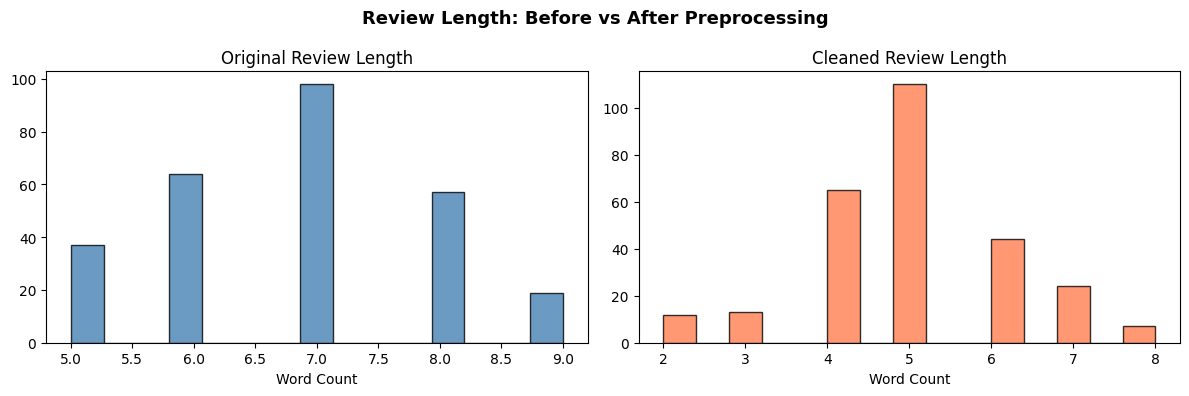

Average words BEFORE: 6.84
Average words AFTER : 4.95


In [32]:
df_full["original_len"] = df_full["review"].apply(lambda x: len(str(x).split()))
df_full["clean_len"]    = df_full["clean_review"].apply(lambda x: len(str(x).split()))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df_full["original_len"], bins=15, color="steelblue",
             edgecolor="black", alpha=0.8)
axes[0].set_title("Original Review Length")
axes[0].set_xlabel("Word Count")

axes[1].hist(df_full["clean_len"], bins=15, color="coral",
             edgecolor="black", alpha=0.8)
axes[1].set_title("Cleaned Review Length")
axes[1].set_xlabel("Word Count")

plt.suptitle("Review Length: Before vs After Preprocessing",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("preprocessing_lengths.png", dpi=150, bbox_inches="tight")
plt.show()
print("Average words BEFORE:", round(df_full["original_len"].mean(), 2))
print("Average words AFTER :", round(df_full["clean_len"].mean(), 2))

In [33]:
if USE_SYNTHETIC:
    X_train_raw = df_train["clean_review"]
    X_test_raw  = df_test["clean_review"]
    y_train     = df_train["sentiment_label"]
    y_test      = df_test["sentiment_label"]
else:
    X = df_full["clean_review"]
    y = df_full["sentiment_label"]
    X_train_raw, X_test_raw, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y)

bow_vec       = CountVectorizer(max_features=5000)
X_train_bow   = bow_vec.fit_transform(X_train_raw)
X_test_bow    = bow_vec.transform(X_test_raw)

tfidf_vec     = TfidfVectorizer(max_features=5000)
X_train_tfidf = tfidf_vec.fit_transform(X_train_raw)
X_test_tfidf  = tfidf_vec.transform(X_test_raw)

print(f"Train: {len(X_train_raw)}  |  Test: {len(X_test_raw)}")
print("BoW   matrix shape:", X_train_bow.shape)
print("TF-IDF matrix shape:", X_train_tfidf.shape)

print("\nTop 15 BoW tokens by frequency:")
bow_freqs = np.asarray(X_train_bow.sum(axis=0)).flatten()
top_bow   = [(bow_vec.get_feature_names_out()[i], bow_freqs[i])
             for i in bow_freqs.argsort()[-15:][::-1]]
for t, c in top_bow:
    print(f"  {t:20s}: {int(c)}")

Train: 264  |  Test: 11
BoW   matrix shape: (264, 136)
TF-IDF matrix shape: (264, 136)

Top 15 BoW tokens by frequency:
  quality             : 60
  product             : 54
  great               : 30
  wrong               : 24
  purchase            : 24
  hai                 : 24
  average             : 24
  worst               : 18
  fit                 : 18
  item                : 18
  absolutely          : 18
  delivery            : 18
  stitching           : 18
  size                : 18
  please              : 18


In [34]:
results = {}
for name, X_tr, X_te in [("BoW",    X_train_bow,   X_test_bow),
                          ("TF-IDF", X_train_tfidf, X_test_tfidf)]:
    clf   = MultinomialNB()
    clf.fit(X_tr, y_train)
    preds = clf.predict(X_te)
    results[name] = {
        "Accuracy": round(accuracy_score(y_test, preds), 4),
        "F1 Score": round(f1_score(y_test, preds,
                                   average="weighted", zero_division=0), 4)
    }

results_df = pd.DataFrame(results).T
print("\n──────────────────────────────────────────")
print("  BoW vs TF-IDF Comparison (Naive Bayes)")
print("──────────────────────────────────────────")
print(results_df.to_string())
print("\nNote: Scores now reflect real generalisation on unseen reviews.")


──────────────────────────────────────────
  BoW vs TF-IDF Comparison (Naive Bayes)
──────────────────────────────────────────
        Accuracy  F1 Score
BoW       0.5455    0.5388
TF-IDF    0.5455    0.5388

Note: Scores now reflect real generalisation on unseen reviews.


In [35]:
analyzer = SentimentIntensityAnalyzer()

def vader_sentiment(text):
    score = analyzer.polarity_scores(str(text))["compound"]
    if   score >=  0.05: return "Positive"
    elif score <= -0.05: return "Negative"
    else:                return "Neutral"

df_full["vader_pred"] = df_full["review"].apply(vader_sentiment)

vader_acc = accuracy_score(df_full["sentiment_label"], df_full["vader_pred"])
vader_f1  = f1_score(df_full["sentiment_label"], df_full["vader_pred"],
                     average="weighted", zero_division=0)

print("VADER Rule-Based Results")
print("─" * 35)
print(f"Accuracy : {vader_acc:.4f}")
print(f"F1 Score : {vader_f1:.4f}")
print("\nDetailed Report:")
print(classification_report(df_full["sentiment_label"],
                             df_full["vader_pred"], zero_division=0))

VADER Rule-Based Results
───────────────────────────────────
Accuracy : 0.6545
F1 Score : 0.6552

Detailed Report:
              precision    recall  f1-score   support

    Negative       0.83      0.74      0.78       125
     Neutral       0.44      0.41      0.43        75
    Positive       0.60      0.75      0.67        75

    accuracy                           0.65       275
   macro avg       0.63      0.63      0.63       275
weighted avg       0.66      0.65      0.66       275



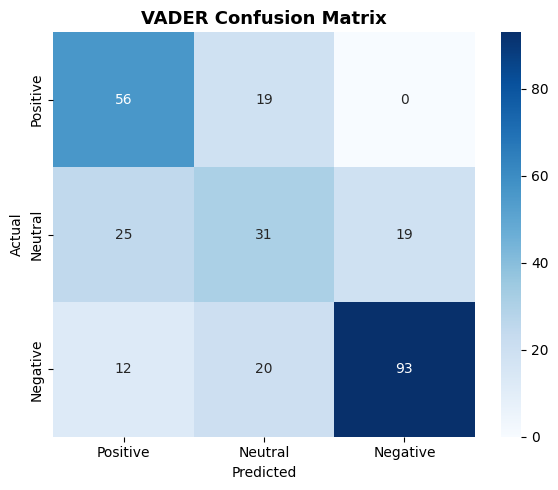

In [36]:
cm_vader = confusion_matrix(df_full["sentiment_label"], df_full["vader_pred"],
                            labels=["Positive", "Neutral", "Negative"])
plt.figure(figsize=(6, 5))
sns.heatmap(cm_vader, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Positive", "Neutral", "Negative"],
            yticklabels=["Positive", "Neutral", "Negative"])
plt.title("VADER Confusion Matrix", fontsize=13, fontweight="bold")
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.tight_layout()
plt.savefig("vader_cm.png", dpi=150, bbox_inches="tight")
plt.show()

In [37]:
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_tfidf, y_train)
lr_preds = lr_model.predict(X_test_tfidf)

lr_acc = accuracy_score(y_test, lr_preds)
lr_f1  = f1_score(y_test, lr_preds, average="weighted", zero_division=0)

print("Logistic Regression Sentiment Results (TF-IDF)")
print("─" * 50)
print(f"Accuracy : {lr_acc:.4f}")
print(f"F1 Score : {lr_f1:.4f}")
print("\nDetailed Report:")
print(classification_report(y_test, lr_preds, zero_division=0))

Logistic Regression Sentiment Results (TF-IDF)
──────────────────────────────────────────────────
Accuracy : 0.3636
F1 Score : 0.3189

Detailed Report:
              precision    recall  f1-score   support

    Negative       0.38      0.60      0.46         5
     Neutral       0.50      0.33      0.40         3
    Positive       0.00      0.00      0.00         3

    accuracy                           0.36        11
   macro avg       0.29      0.31      0.29        11
weighted avg       0.31      0.36      0.32        11



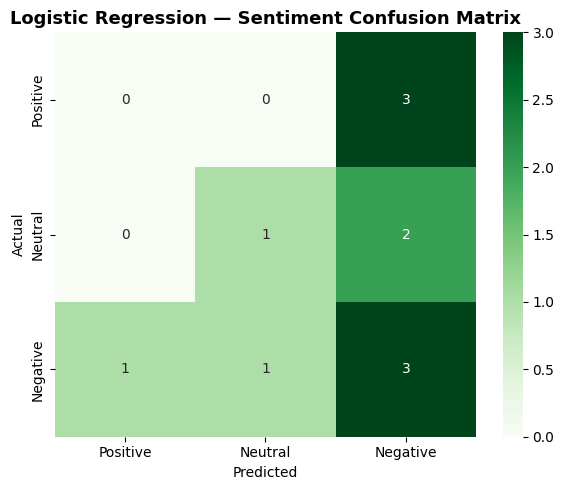

In [38]:
cm_lr = confusion_matrix(y_test, lr_preds,
                         labels=["Positive", "Neutral", "Negative"])
plt.figure(figsize=(6, 5))
sns.heatmap(cm_lr, annot=True, fmt="d", cmap="Greens",
            xticklabels=["Positive", "Neutral", "Negative"],
            yticklabels=["Positive", "Neutral", "Negative"])
plt.title("Logistic Regression — Sentiment Confusion Matrix",
          fontsize=13, fontweight="bold")
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.tight_layout()
plt.savefig("lr_cm.png", dpi=150, bbox_inches="tight")
plt.show()

Intent distribution:
intent_label
General Query     150
Complaint          99
Refund Request     13
Delivery Issue     13
Name: count, dtype: int64


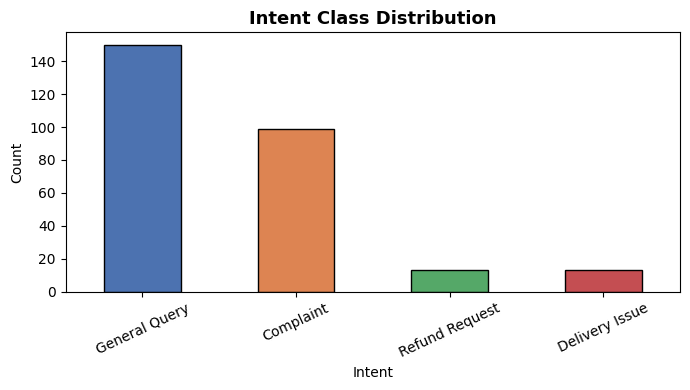

In [39]:
def assign_intent(text):
    text = str(text).lower()
    if any(w in text for w in ["refund", "money back", "paisa wapas",
                                "charged twice", "billing"]):
        return "Refund Request"
    elif any(w in text for w in ["delivery", "shipping", "arrived", "late",
                                  "kab ayega", "package", "not received",
                                  "never arrived", "missing"]):
        return "Delivery Issue"
    elif any(w in text for w in ["broken", "damaged", "wrong item", "worst",
                                  "terrible", "unacceptable", "poor", "ghatia",
                                  "kharab", "zipper", "wrong color", "broke"]):
        return "Complaint"
    else:
        return "General Query"

if "intent_label" not in df_full.columns:
    df_full["intent_label"] = df_full["review"].apply(assign_intent)

print("Intent distribution:")
print(df_full["intent_label"].value_counts())

plt.figure(figsize=(7, 4))
df_full["intent_label"].value_counts().plot(
    kind="bar",
    color=["#4C72B0", "#DD8452", "#55A868", "#C44E52"],
    edgecolor="black")
plt.title("Intent Class Distribution", fontsize=13, fontweight="bold")
plt.xlabel("Intent"); plt.ylabel("Count")
plt.xticks(rotation=25)
plt.tight_layout()
plt.savefig("intent_dist.png", dpi=150, bbox_inches="tight")
plt.show()

In [40]:
if USE_SYNTHETIC:
    Xi_train = df_train["clean_review"]
    Xi_test  = df_test["clean_review"]
    yi_train = df_train["intent_label"]
    yi_test  = df_test["intent_label"]
else:
    Xi = df_full["clean_review"]
    yi = df_full["intent_label"]
    Xi_train, Xi_test, yi_train, yi_test = train_test_split(
        Xi, yi, test_size=0.2, random_state=42, stratify=yi)

tfidf_i    = TfidfVectorizer(max_features=5000)
Xi_train_v = tfidf_i.fit_transform(Xi_train)
Xi_test_v  = tfidf_i.transform(Xi_test)

intent_model = LogisticRegression(max_iter=1000, random_state=42)
intent_model.fit(Xi_train_v, yi_train)
intent_preds = intent_model.predict(Xi_test_v)

print("Intent Classification Report")
print("─" * 50)
print(classification_report(yi_test, intent_preds, zero_division=0))

Intent Classification Report
──────────────────────────────────────────────────
                precision    recall  f1-score   support

     Complaint       0.00      0.00      0.00         3
Delivery Issue       0.00      0.00      0.00         1
 General Query       0.60      1.00      0.75         6
Refund Request       0.00      0.00      0.00         1

      accuracy                           0.55        11
     macro avg       0.15      0.25      0.19        11
  weighted avg       0.33      0.55      0.41        11



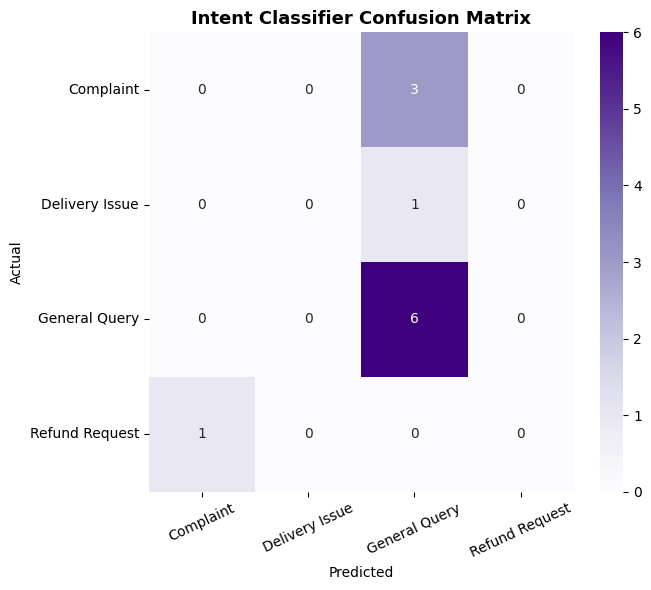

In [41]:
labels_i = sorted(df_full["intent_label"].unique())
cm_i = confusion_matrix(yi_test, intent_preds, labels=labels_i)

plt.figure(figsize=(7, 6))
sns.heatmap(cm_i, annot=True, fmt="d", cmap="Purples",
            xticklabels=labels_i, yticklabels=labels_i)
plt.title("Intent Classifier Confusion Matrix", fontsize=13, fontweight="bold")
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.xticks(rotation=25); plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig("intent_cm.png", dpi=150, bbox_inches="tight")
plt.show()

In [42]:
n_topics    = 5
tfidf_topic = TfidfVectorizer(max_features=1000, min_df=2, max_df=0.90)
X_topic     = tfidf_topic.fit_transform(df_full["clean_review"])
feature_names = tfidf_topic.get_feature_names_out()

nmf_model = NMF(n_components=n_topics, random_state=42, max_iter=400)
W = nmf_model.fit_transform(X_topic)
H = nmf_model.components_

n_top_words = 10
print("NMF Raw Keywords (inspect before labelling)")
print("=" * 50)
raw_keywords = {}
for i, topic in enumerate(H):
    top_idx = topic.argsort()[-n_top_words:][::-1]
    top_kws = [feature_names[j] for j in top_idx]
    raw_keywords[i] = top_kws
    print(f"\nTopic {i+1}: {', '.join(top_kws)}")

def label_topic(keywords):
    kw = set(keywords)
    if kw & {"quality", "material", "stitching", "price", "worth"}:
        return "Product Quality"
    elif kw & {"fit", "size", "guide", "true", "expected"}:
        return "Sizing & Fit"
    elif kw & {"delivery", "shipping", "arrived", "package", "late"}:
        return "Delivery & Shipping"
    elif kw & {"refund", "return", "money", "paisa", "damaged", "replacement"}:
        return "Returns & Refunds"
    else:
        return "General Feedback"

topic_labels = {i: label_topic(raw_keywords[i]) for i in range(n_topics)}

print("\n\nFinal Topic Labels:")
print("─" * 50)
for i in range(n_topics):
    print(f"Topic {i+1} — {topic_labels[i]}: {', '.join(raw_keywords[i])}")

df_full["dominant_topic"] = W.argmax(axis=1)
df_full["topic_name"]     = df_full["dominant_topic"].map(topic_labels)

print("\nDocument-Topic Distribution:")
print(df_full["topic_name"].value_counts())

NMF Raw Keywords (inspect before labelling)

Topic 1: quality, average, price, hai, theek, thak, better, expected, reasonable, terrible

Topic 2: great, happy, bad, fine, material, stitching, work, beautiful, purchase, fitting

Topic 3: product, delivery, fast, okay, shown, exactly, love, special, nothing, arrived

Topic 4: worst, wrong, ever, completely, experience, size, better, never, buying, photo

Topic 5: money, waste, complete, buy, nothing, described, special, okay, decent, color


Final Topic Labels:
──────────────────────────────────────────────────
Topic 1 — Product Quality: quality, average, price, hai, theek, thak, better, expected, reasonable, terrible
Topic 2 — Product Quality: great, happy, bad, fine, material, stitching, work, beautiful, purchase, fitting
Topic 3 — Delivery & Shipping: product, delivery, fast, okay, shown, exactly, love, special, nothing, arrived
Topic 4 — Sizing & Fit: worst, wrong, ever, completely, experience, size, better, never, buying, photo
Topi

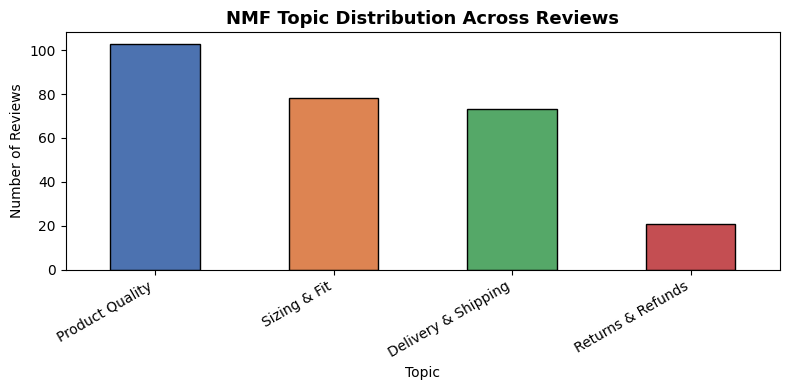

In [43]:
plt.figure(figsize=(8, 4))
topic_counts = df_full["topic_name"].value_counts()
colors = ["#4C72B0", "#DD8452", "#55A868", "#C44E52", "#8172B2"]
topic_counts.plot(kind="bar", color=colors[:len(topic_counts)],
                  edgecolor="black")
plt.title("NMF Topic Distribution Across Reviews",
          fontsize=13, fontweight="bold")
plt.xlabel("Topic"); plt.ylabel("Number of Reviews")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig("topic_dist.png", dpi=150, bbox_inches="tight")
plt.show()

In [44]:
models = {
    "VADER (Rule-Based)":    (df_full["sentiment_label"], df_full["vader_pred"]),
    "LR Sentiment (TF-IDF)": (y_test,  lr_preds),
    "LR Intent (TF-IDF)":    (yi_test, intent_preds),
}

rows = []
for name, (y_true, y_pred) in models.items():
    rows.append({
        "Model":     name,
        "Accuracy":  round(accuracy_score(y_true, y_pred), 4),
        "Precision": round(precision_score(y_true, y_pred,
                           average="weighted", zero_division=0), 4),
        "Recall":    round(recall_score(y_true, y_pred,
                           average="weighted", zero_division=0), 4),
        "F1 Score":  round(f1_score(y_true, y_pred,
                           average="weighted", zero_division=0), 4),
    })

eval_df = pd.DataFrame(rows).set_index("Model")
print("\n" + "=" * 65)
print("  COMPREHENSIVE MODEL EVALUATION SUMMARY")
print("=" * 65)
print(eval_df.to_string())
print()
print("Most Suitable Metric: F1 Score (Weighted)")
print("  Reason: Class-imbalanced dataset — weighted F1 balances")
print("  Precision & Recall across all classes fairly.")


  COMPREHENSIVE MODEL EVALUATION SUMMARY
                       Accuracy  Precision  Recall  F1 Score
Model                                                       
VADER (Rule-Based)       0.6545     0.6624  0.6545    0.6552
LR Sentiment (TF-IDF)    0.3636     0.3068  0.3636    0.3189
LR Intent (TF-IDF)       0.5455     0.3273  0.5455    0.4091

Most Suitable Metric: F1 Score (Weighted)
  Reason: Class-imbalanced dataset — weighted F1 balances
  Precision & Recall across all classes fairly.


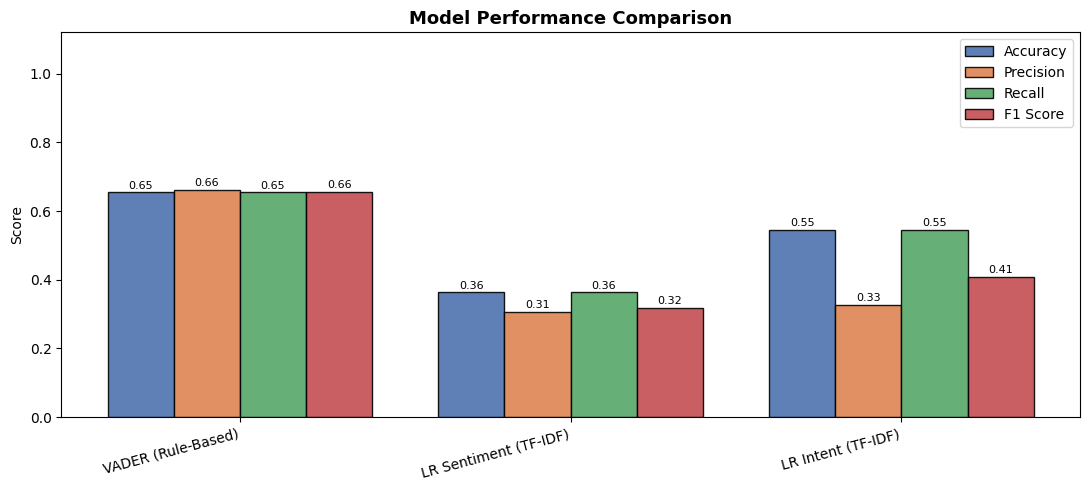

In [45]:
eval_df_reset = eval_df.reset_index()
x       = np.arange(len(eval_df_reset))
width   = 0.2
metrics = ["Accuracy", "Precision", "Recall", "F1 Score"]
colors  = ["#4C72B0", "#DD8452", "#55A868", "#C44E52"]

fig, ax = plt.subplots(figsize=(11, 5))
for idx, (metric, color) in enumerate(zip(metrics, colors)):
    bars = ax.bar(x + idx * width, eval_df_reset[metric], width,
                  label=metric, color=color, edgecolor="black", alpha=0.9)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.005,
                f"{bar.get_height():.2f}",
                ha="center", va="bottom", fontsize=8)

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(eval_df_reset["Model"], rotation=15, ha="right")
ax.set_ylim(0, 1.12)
ax.set_ylabel("Score")
ax.set_title("Model Performance Comparison",
             fontsize=13, fontweight="bold")
ax.legend(loc="upper right")
plt.tight_layout()
plt.savefig("model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

In [46]:
import gradio as gr

def analyze_review(text):
    if not text.strip():
        return "Please enter a review.", "", ""

    vs = analyzer.polarity_scores(text)["compound"]
    if   vs >=  0.05: sentiment = f"😊 Positive  (VADER score: {vs:.3f})"
    elif vs <= -0.05: sentiment = f"😞 Negative  (VADER score: {vs:.3f})"
    else:             sentiment = f"😐 Neutral   (VADER score: {vs:.3f})"

    clean   = preprocess(text)
    vec_s   = tfidf_vec.transform([clean])
    ml_pred = lr_model.predict(vec_s)[0]
    ml_prob = lr_model.predict_proba(vec_s).max()
    sentiment += f"\n🤖 ML Prediction: {ml_pred} (confidence: {ml_prob:.2f})"

    vec_i       = tfidf_i.transform([clean])
    intent      = intent_model.predict(vec_i)[0]
    intent_prob = intent_model.predict_proba(vec_i).max()
    intent_out  = f"🏷️ {intent}  (confidence: {intent_prob:.2f})"

    vec_t      = tfidf_topic.transform([clean])
    topic_idx  = nmf_model.transform(vec_t).argmax()
    topic_name = topic_labels[topic_idx]
    top_kw     = [feature_names[j]
                  for j in nmf_model.components_[topic_idx].argsort()[-8:][::-1]]
    topic_out  = f"📌 {topic_name}\n🔑 Keywords: {', '.join(top_kw)}"

    return sentiment, intent_out, topic_out


demo = gr.Interface(
    fn=analyze_review,
    inputs=gr.Textbox(
        lines=4,
        placeholder="Type a customer review here (English or Roman Urdu)...",
        label="Customer Review"
    ),
    outputs=[
        gr.Textbox(label="Sentiment Analysis"),
        gr.Textbox(label="Intent Classification"),
        gr.Textbox(label="Topic & Keywords"),
    ],
    title="🛍️ Customer Reviews Intelligence System",
    description=(
        "Enter a customer review to get:\n"
        "• Sentiment — Rule-based VADER + ML Logistic Regression\n"
        "• Intent — Complaint / Refund Request / Delivery Issue / General Query\n"
        "• Dominant Topic with Key Keywords (NMF)"
    ),
    examples=[
        ["The dress is absolutely beautiful and fits perfectly!"],
        ["Worst product ever, I want a full refund immediately!"],
        ["My package has not arrived yet, delivery is very late."],
        ["Yeh product bohat ghatia hai, paisa wapas karo!"],
        ["Average quality, nothing special about this item."],
    ],
    theme="soft"
)

demo.launch(share=True)

* Running on local URL:  http://127.0.0.1:7861
* Running on public URL: https://feba4d3ef1580f4968.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
